# Macro Density Analysis: Nutritional Structure Exploration

This notebook explores the latent structure of food nutrition using multivariate statistical analysis and unsupervised learning techniques.

## Research Objective

This project investigates the following question:
- Can foods be grouped by nutritional density patterns?
- What latent dimensions define the structure of food composition?
- Can multivariate statistical techniques reveal hidden nutritional clusters?

Rather than analyzing nutruents independently, this study treats nutrition as a high-dimensional structured space.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

## Dataset Overview

The dataset used in this analysis is the USDA Food Composition Dataset, which contains detailed nutritional information for a wide range of foods.
Each food item includes macro and micronutrient measurements, allowing for statistical exploration of nutritional patterns.

In [2]:
df = pd.read_csv("../data/USDA.csv")
df.head()

,ID,Description,Calories,Protein,TotalFat,Carbohydrate,Sodium,SaturatedFat,Cholesterol,Sugar,Calcium,Iron,Potassium,VitaminC,VitaminE,VitaminD
0,1001,"BUTTER,WITH SALT",717.0,0.85,81.11,0.06,714.0,51.368,215.0,0.06,24.0,0.02,24.0,0.0,2.32,1.5
1,1002,"BUTTER,WHIPPED,WITH SALT",717.0,0.85,81.11,0.06,827.0,50.489,219.0,0.06,24.0,0.16,26.0,0.0,2.32,1.5
2,1003,"BUTTER OIL,ANHYDROUS",876.0,0.28,99.48,0.00,2.0,61.924,256.0,0.00,4.0,0.00,5.0,0.0,2.80,1.8
3,1004,"CHEESE,BLUE",353.0,21.40,28.74,2.34,1395.0,18.669,75.0,0.50,528.0,0.31,256.0,0.0,0.25,0.5
4,1005,"CHEESE,BRICK",371.0,23.24,29.68,2.79,560.0,18.764,94.0,0.51,674.0,0.43,136.0,0.0,0.26,0.5


## Dataset Structure

Before conducting statistical analysis, we first examine the structure of the dataset, including the number of observations, feature types, and potential missing values.

In [3]:
df.shape

(7058, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7058 entries, 0 to 7057
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            7058 non-null   int64  
 1   Description   7058 non-null   str    
 2   Calories      7057 non-null   float64
 3   Protein       7057 non-null   float64
 4   TotalFat      7057 non-null   float64
 5   Carbohydrate  7057 non-null   float64
 6   Sodium        6974 non-null   float64
 7   SaturatedFat  6757 non-null   float64
 8   Cholesterol   6770 non-null   float64
 9   Sugar         5148 non-null   float64
 10  Calcium       6922 non-null   float64
 11  Iron          6935 non-null   float64
 12  Potassium     6649 non-null   float64
 13  VitaminC      6726 non-null   float64
 14  VitaminE      4338 non-null   float64
 15  VitaminD      4224 non-null   float64
dtypes: float64(14), int64(1), str(1)
memory usage: 882.4 KB


In [5]:
df.describe()

,ID,Calories,Protein,TotalFat,Carbohydrate,Sodium,SaturatedFat,Cholesterol,Sugar,Calcium,Iron,Potassium,VitaminC,VitaminE,VitaminD
count,7058.000000,7057.000000,7057.000000,7057.000000,7057.000000,6974.000000,6757.000000,6770.000000,5148.000000,6922.000000,6935.000000,6649.000000,6726.000000,4338.000000,4224.000000
mean,14259.821196,219.695338,11.710368,10.320614,20.697860,322.059220,3.452267,41.551994,8.256540,73.530627,2.828368,301.357949,9.435980,1.487462,0.576918
std,8577.179705,172.198755,10.919356,16.814191,27.630443,1045.416931,6.921267,122.963028,15.361509,222.445338,6.019878,415.638949,71.256536,5.386914,4.301147
min,1001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8387.250000,85.000000,2.290000,0.720000,0.000000,37.000000,0.172000,0.000000,0.000000,9.000000,0.520000,135.000000,0.000000,0.120000,0.000000
50%,13293.500000,181.000000,8.200000,4.370000,7.130000,79.000000,1.256000,3.000000,1.395000,19.000000,1.330000,250.000000,0.000000,0.270000,0.000000
75%,18336.750000,331.000000,20.430000,12.700000,28.170000,386.000000,4.028000,69.000000,7.875000,56.000000,2.620000,348.000000,3.100000,0.710000,0.100000
max,93600.000000,902.000000,88.320000,100.000000,100.000000,38758.000000,95.600000,3100.000000,99.800000,7364.000000,123.600000,16500.000000,2400.000000,149.400000,250.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Check for negative values
numeric_df = df.select_dtypes(include="number")
(numeric_df < 0).sum()

ID              0
Calories        0
Protein         0
TotalFat        0
Carbohydrate    0
Sodium          0
SaturatedFat    0
Cholesterol     0
Sugar           0
Calcium         0
Iron            0
Potassium       0
VitaminC        0
VitaminE        0
VitaminD        0
dtype: int64

In [8]:
# Missing values check
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

VitaminD        2834
VitaminE        2720
Sugar           1910
Potassium        409
VitaminC         332
SaturatedFat     301
Cholesterol      288
Calcium          136
Iron             123
Sodium            84
Calories           1
Protein            1
TotalFat           1
Carbohydrate       1
dtype: int64

### Missing Ratio Analysis
To determine whether missing values require treatment, we calculate the proportion of missing values per feature.

In [9]:
# Missing value ratio check
missing_ratio = df.isnull().mean().sort_values(ascending=False)
missing_ratio

VitaminD        0.401530
VitaminE        0.385378
Sugar           0.270615
Potassium       0.057948
VitaminC        0.047039
SaturatedFat    0.042647
Cholesterol     0.040805
Calcium         0.019269
Iron            0.017427
Sodium          0.011901
Calories        0.000142
Protein         0.000142
TotalFat        0.000142
Carbohydrate    0.000142
Description     0.000000
ID              0.000000
dtype: float64

In [10]:
# Create filled version(do not overwrite original)
df_filled = df.fillna(0)

# Confirm
df_filled.isnull().sum().sum()

np.int64(0)

In [11]:
df.dtypes
# Check non-numeric columns (except indentifiers / names if any)
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
non_numeric_cols

['Description']

In [12]:
# Percentile-based extreme value scan
summary = df_filled.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
summary[["min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max"]]

,min,1%,5%,25%,50%,75%,95%,99%,max
ID,1001.0,1079.57,4541.85,8387.250,13293.500,18336.75000,35022.1500,43334.87000,93600.00
Calories,0.0,7.57,24.00,85.000,181.000,331.00000,527.0000,884.00000,902.00
Protein,0.0,0.00,0.07,2.290,8.200,20.42750,29.2300,36.16430,88.32
TotalFat,0.0,0.00,0.05,0.720,4.365,12.69750,37.1130,100.00000,100.00
Carbohydrate,0.0,0.00,0.00,0.000,7.130,28.17000,80.0000,89.44300,100.00
Sodium,0.0,0.00,1.00,35.000,77.000,383.00000,1089.0000,2071.86000,38758.00
SaturatedFat,0.0,0.00,0.00,0.114,1.120,3.81225,12.6400,28.45611,95.60
Cholesterol,0.0,0.00,0.00,0.000,2.000,68.00000,106.1500,360.72000,3100.00
Sugar,0.0,0.00,0.00,0.000,0.000,4.07750,37.8100,65.21500,99.80
Calcium,0.0,0.00,0.00,9.000,19.000,54.00000,279.1500,960.43000,7364.00


## Nutrient Distribution Analysis

To understand the statistical structure of the dataset, we examine the distribution of several key nutritional variables, including calories, protein, fat, and carbohydrates.
Distribution plots help reveal skewness, outliers, and general patterns in nutritional density.

In [13]:
df_filled.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,7058.0,14259.821196,8577.179705,1001.0,8387.250,13293.500,18336.75000,93600.00
Calories,7058.0,219.664211,172.206410,0.0,85.000,181.000,331.00000,902.00
Protein,7058.0,11.708709,10.919472,0.0,2.290,8.200,20.42750,88.32
TotalFat,7058.0,10.319151,16.813449,0.0,0.720,4.365,12.69750,100.00
Carbohydrate,7058.0,20.694928,27.629584,0.0,0.000,7.130,28.17000,100.00
Sodium,7058.0,318.226268,1039.763266,0.0,35.000,77.000,383.00000,38758.00
SaturatedFat,7058.0,3.305040,6.807890,0.0,0.114,1.120,3.81225,95.60
Cholesterol,7058.0,39.856475,120.708085,0.0,0.000,2.000,68.00000,3100.00
Sugar,7058.0,6.022198,13.622256,0.0,0.000,0.000,4.07750,99.80
Calcium,7058.0,72.113772,220.523285,0.0,9.000,19.000,54.00000,7364.00


### Distribution Summary Interpretation

The majority of nutritional variables demonstrate right-skewed behavior, as indicated by mean values exceeding median values.

Micronutrients such as Vitamin D and Vitamin C are highly sparse, with median values equal to zero, indicating uneven distribution across foods.

Sodium, calcium and Potassium show extreme heavy-tail properties, suggesting potential influence of outliers in multivariate modeling.

In [14]:
# Skewness ranking
skewness = df_filled.skew(numeric_only=True).sort_values(ascending=False)
skewness

VitaminD        60.133350
VitaminC        27.115162
Sodium          20.674359
Cholesterol     14.999503
Potassium       14.365420
Calcium         13.284214
VitaminE        12.602929
SaturatedFat     6.881767
Iron             6.645845
TotalFat         3.331222
Sugar            3.199996
ID               1.681349
Calories         1.316567
Carbohydrate     1.275261
Protein          1.166856
dtype: float64

### Skewness Structure Interpretation

The skewness ranking reveals a highly non-normal nutritional space.

Several micronutrients(Vitamin D, Vitamin C, Sodium, Cholesterol, Potassium, Calcium, Vitamin E) exhibit extreme right skewness (skewness > 10), indicating heavy-tailed and sparse distributions. These nutrients are present in very small amounts in most foods but appear in extreme concentrations in specific food categories.

Macronutrients such as Calories, Carbohydrate and Protein show moderate right skewness (skewness ≈ 1–1.5), suggesting more stable density patterns across food items.

This confirms that the nutritional feature space is highly heterogeneous and may require transformation before multivariate modeling.

### Calorie Distribution Characteristics

Calories exhibit moderate right skewness (skewness ≈ 1.3), indicating that most foods cluster around lower to moderate energy density, while a smaller subset of high-calorie foods (e.g., oils and processed items) extends the upper tail.

This suggests that energy density is relatively stable compared to micronutrients, yet still influenced by concentrated fat-based food categories.

### Protein Distribution Characteristics

Protein exhibits moderate right skewness (skewness ≈ 1.7), suggesting that most foods contain lower to moderate protein density, while a smaller subset of high-protein foods (e.g., meats, fish, legumes) extends the upper tail.

Compared to micronutrients, protein distribution is less extreme and shows a more continuous density structure across food items.
This suggests that protein behaves as a core macronutrient axis rather than a sparse, rather than a sparse and highly concentrated variable.

### Motivation for Log Transformation

Many nutritional variables exhibit strong right skewness distributions, with a small number of foods containing extremely high nutrient concentrations.

Such heavy-tailed distributions may distort variance structure and negatively affect multivariate modeling techniques such as PCA and clustering. Therefore, a log transformation is applied to stabilize the feature space.

In [15]:
# Log1p transformation comparisons
numeric_cols = [c for c in df_filled.columns if c not in ["ID", "Description"]]

# Before(original skewness)
skew_before = df_filled[numeric_cols].skew(numeric_only=True).sort_values(ascending=False)

# Apply log1p transformation only to numeric columns
df_log = df_filled.copy()
df_log[numeric_cols] = np.log1p(df_log[numeric_cols])

#After (log1p skewness)
skew_after = df_log[numeric_cols].skew(numeric_only=True).sort_values(ascending=False)

#Comparison table
skew_compare = (
    pd.concat([skew_before.rename("before"), skew_after.rename("after")], axis=1)
      .assign(reduction=lambda d: d["before"] - d["after"])
      .sort_values("before", ascending=False)
)
skew_compare

,before,after,reduction
VitaminD,60.133350,4.460430,55.672919
VitaminC,27.115162,1.595856,25.519306
Sodium,20.674359,-0.480490,21.154849
Cholesterol,14.999503,0.361296,14.638207
Potassium,14.365420,-1.849521,16.214941
Calcium,13.284214,0.177845,13.106369
VitaminE,12.602929,3.430797,9.172132
SaturatedFat,6.881767,0.846549,6.035218
Iron,6.645845,1.357332,5.288513
TotalFat,3.331222,0.303905,3.027317


### Log-Transformation Effect on Nutritional Skewness

Applying the log1p transformation significantly reduces extreme right skewness in micronutrients.

Variables such as Vitamin D, Vitamin C, Sodium, and Calcium show dramatic skewness reduction, indicating that heavy-tail effects were primarily driven by extreme high-density observations.

After transformation:
- Most variables fall within a moderate skewness range (-2 to 2).
- Several previously highly skewed distributions become approximately symmetric.
- A few variables exhibit mild left-skew due to compression of extreme values.

## Macronutrient Structure

## Protein density concentration

In [16]:
# Protein distribution percentiles 
protein_summary =df_filled["Protein"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)
protein_summary

count    7058.000000
mean       11.708709
std        10.919472
min         0.000000
1%          0.000000
5%          0.070000
25%         2.290000
50%         8.200000
75%        20.427500
95%        29.230000
99%        36.164300
max        88.320000
Name: Protein, dtype: float64

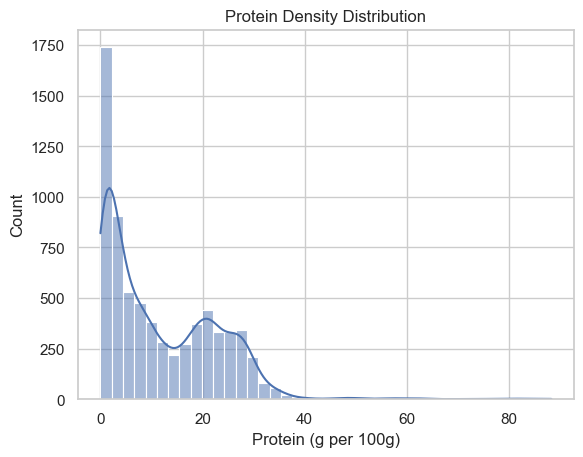

In [17]:
# Protein density visualization using histplot
sns.histplot(df_filled["Protein"], bins=40, kde=True)
plt.title("Protein Density Distribution")
plt.xlabel("Protein (g per 100g)")
plt.ylabel("Count")
plt.show()

### Protein Density Distribution Analysis

Protein density shows moderate concentration in the lower range of the nutritional space.Approximately 25% of foods contain less than 2.29 g of protein, while the median protein density is 8.2 g. Around 75% of foods contain less than 20.4 g of protein.

The histogram confirms a right skewness distribution with a strong concentration of foods in the low-protein range (0–10 g).

A secondary density region appears around 15–25 g, likely corresponding to protein-rich food categories.

The distribution extends into a long upper tail (above 40 g), but extremely high-protein foods remain relatively rare.

Overall, protein density forms a continuous macronutrient axis rather than a sparse or burst-type structure, reinforcing its role as a stable modeling feature in the nutritional space.

### Sugar Distribution Characteristics

In [18]:
# Sugar distribution percentiles 
sugar_summary =df_filled["Sugar"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)
sugar_summary

count    7058.000000
mean        6.022198
std        13.622256
min         0.000000
1%          0.000000
5%          0.000000
25%         0.000000
50%         0.000000
75%         4.077500
95%        37.810000
99%        65.215000
max        99.800000
Name: Sugar, dtype: float64

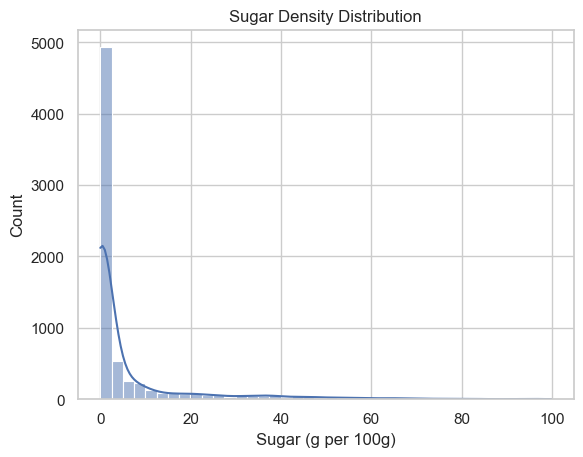

In [19]:
# Sugar density visualization using histplot
sns.histplot(df_filled["Sugar"], bins=40, kde=True)
plt.title("Sugar Density Distribution")
plt.xlabel("Sugar (g per 100g)")
plt.ylabel("Count")
plt.show()

### Sugar Distribution Analysis

Sugar exhibits a strongly zero-inflated distribution. Approximately 50% of foods contain 0 g of sugar, and the distribution remains at zero up to the median, indicating a large no-sugar group. A sharp transition occurs between the 50th and 75th percentiles, where sugar values rise to approximately 4.08 g.

The histogram confirms a dominant spike at zero, showing that a large proportion of foods contain no sugar. Beyond zero, the frequency declines rapidly, indicating that sugar-containing foods represent a minority of the dataset.

The distribution extends into a long right tail. The 95th percentile reaches 37.8 g and the 99th percentile reaches 65.2 g, suggesting that high-sugar foods form a distinct upper-tail group. Values approaching 100 g likely correspond to highly processed or sweetened food categories.

Overall, the pattern indicates that sugar behaves as a zero-inflated, burst-type feature rather than a continuous macronutrient axis.

### Fat Distribution Characteristics

In [20]:
# Total Fat distribution percentiles 
fat_summary =df_filled["TotalFat"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)
fat_summary

count    7058.000000
mean       10.319151
std        16.813449
min         0.000000
1%          0.000000
5%          0.050000
25%         0.720000
50%         4.365000
75%        12.697500
95%        37.113000
99%       100.000000
max       100.000000
Name: TotalFat, dtype: float64

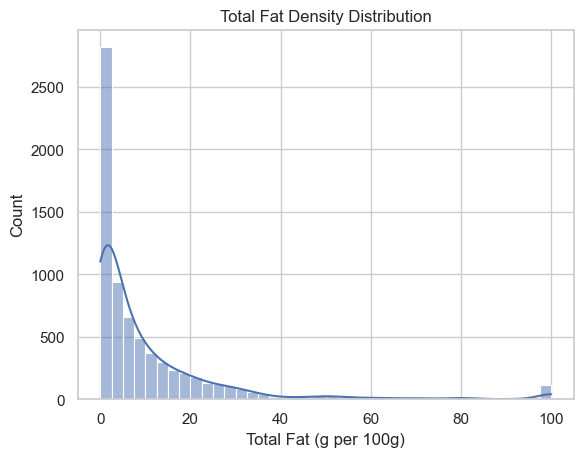

In [21]:
# Fat density visualization using histplot
sns.histplot(df_filled["TotalFat"], bins=40, kde=True)
plt.title("Total Fat Density Distribution")
plt.xlabel("Total Fat (g per 100g)")
plt.ylabel("Count")
plt.show()

### Total Fat Distribution Analysis

Total fat exhibits a continuous but right-skewed distribution across the dataset. Approximately 25% of foods contain less than 0.72 g of fat, while the median fat density is 4.37 g. Around 75% of foods contain less than 12.7 g of fat.

The histogram reveals a dominant peak in the low-fat range (0–5 g), indicating that most foods contain relatively small amounts of fat.

The upper tail extends toward 100 g, with the 99th percentile equal to the maximum value. This indicates a distinct category of pure-fat foods such as oils, representing structural category limits rather than burst-type outliers.

Overall, the distribution confirms that fat functions as a continuous energy-density axis within the nutritional feature space.

### Sugar vs Fat Structural Comparison

Although both sugar and fat are macronutrients, their statistical structures differ substantially.

Sugar exhibits a strongly zero-inflated distribution, with 50% of foods containing no sugar at all. Its density pattern is characterized by a dominant zero group and a burst-type upper tail corresponding to sweetened or processed foods.

Unlike sugar, fat is not strongly zero-inflated. Instead, fat values increase smoothly across the density spectrum, suggesting that most foods contain at least some fat.

This distinction highlights that not all macronutrients form equivalent axes in the nutritional space. Fat behaves as a structural energy-density axis, while sugar functions as a categorical burst-type feature.

In [22]:
## Micronutrient Variance

In [23]:
# Micronutrient variance analysis
micronutrients = [
    "Sodium",
    "Calcium",
    "Iron",
    "Potassium",
    "VitaminC",
    "VitaminE",
    "VitaminD"
]
micronutrient_var = df_filled[micronutrients].var().sort_values(ascending=False)
micronutrient_var

Sodium       1.081108e+06
Potassium    1.677018e+05
Calcium      4.863052e+04
VitaminC     4.842613e+03
Iron         3.574431e+01
VitaminE     1.835817e+01
VitaminD     1.115055e+01
dtype: float64

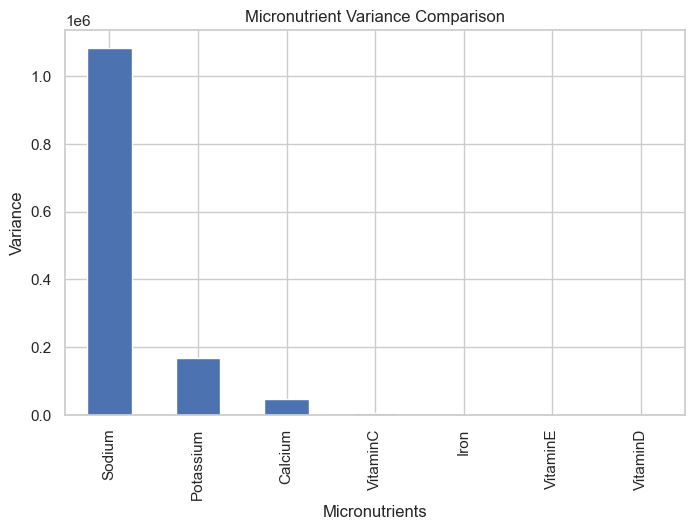

In [24]:
# Nicronutrient variance visualization using bar chart
plt.figure(figsize=(8,5))
micronutrient_var.sort_values(ascending=False).plot(kind="bar")
plt.title("Micronutrient Variance Comparison")
plt.xlabel("Micronutrients")
plt.ylabel("Variance")
plt.show()

### Micronutrient Variance Structure

Micronutrients display heterogeneous variance patterns across the dataset.

Among the analyzed nutrients, sodium shows the highest variance, followed by potassium and calcium. These nutrients appear in highly variable concentrations across different food categories, resulting in large dispersion in their distributions.

Other micronutrients, such as vitamin C, iron, vitamin E, and vitamin D, exhibit much lower variance, indicating comparatively narrower concentration ranges across foods.

It is important to note that variance differences may partially reflect differences in measurement scales (e.g., mg and µg) in addition to true nutritional variability. Standardization will therefore be applied in later modeling stages to remove scale effects.

Overall, this variance structure suggests that certain micronutrients serve as stronger differentiating signals across food categories within the nutritional feature space.

## Correlation Strudture Analysis

### Standardization for Structural Modeling

Nutritional variables are measured on very different numerical scales. To make the feature space comparable across variables, standardization is applied before structural modeling. 

This transforms each variable to common scale with mean 0 and standard deviation 1.

In [25]:
from sklearn.preprocessing import StandardScaler

# Standardize nutritional variables for structural modeling
features = [ 
    "Calories", "Protein", "TotalFat", "Carbohydrate",  "Sodium","SaturatedFat", "Cholesterol", 
    "Sugar", "Calcium", "Iron", "Potassium", "VitaminC", "VitaminE", "VitaminD" ]
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_filled[features]),
    columns=features,
    index=df_filled.index
)
df_scaled.head()

,Calories,Protein,TotalFat,Carbohydrate,Sodium,SaturatedFat,Cholesterol,Sugar,Calcium,Iron,Potassium,VitaminC,VitaminE,VitaminD
0,2.888226,-0.994506,4.210669,-0.746895,0.380665,7.060391,1.451070,-0.437712,-0.218195,-0.461521,-0.634687,-0.129227,0.328119,0.345831
1,2.888226,-0.994506,4.210669,-0.746895,0.489352,6.931267,1.484211,-0.437712,-0.218195,-0.438102,-0.629802,-0.129227,0.328119,0.345831
2,3.811602,-1.046710,5.303324,-0.749066,-0.304154,8.611055,1.790757,-0.442117,-0.308895,-0.464866,-0.681086,-0.129227,0.440155,0.435678
3,0.774334,0.887587,1.095680,-0.664369,1.035668,2.256947,0.291165,-0.405409,2.067439,-0.413011,-0.068121,-0.129227,-0.155036,0.046341
4,0.878867,1.056105,1.151591,-0.648081,0.232544,2.270903,0.448581,-0.404675,2.729548,-0.392939,-0.361172,-0.129227,-0.152702,0.046341


In [26]:
# Check mean and standard deviation after standardization
df_scaled.agg(["mean", "std"]).round(2)

,Calories,Protein,TotalFat,Carbohydrate,Sodium,SaturatedFat,Cholesterol,Sugar,Calcium,Iron,Potassium,VitaminC,VitaminE,VitaminD
mean,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Standardization Check

The transformed dataset shows that each nutritional variable has been rescaled to a comparable range.

This does not remove structural relationships between variables. Instead, it ensures that later multivariate methods operate on a balanced feature space rather than being dominated by variables with large raw magnitudes.

### Pearson Correlation Matrix

Nutritional variables often exhibit structural dependencies due to shared biochemical composition or common food source.

To investiage these relationships, we compute the Pearson correlation matrix across all standardized nutritional variables. This matrix quantifies the strength and direction of linear relationships between nutrients.

In [27]:
# Compute Pearson correlation matrix
corr_matrix = df_scaled.corr()
corr_matrix

,Calories,Protein,TotalFat,Carbohydrate,Sodium,SaturatedFat,Cholesterol,Sugar,Calcium,Iron,Potassium,VitaminC,VitaminE,VitaminD
Calories,1.000000,0.135426,0.807766,0.434769,0.034253,0.604240,0.032759,0.269180,0.112235,0.191981,0.088625,-0.028830,0.314840,0.073771
Protein,0.135426,1.000000,0.061769,-0.284352,-0.002911,0.056060,0.280131,-0.251414,0.044459,0.137937,0.240141,-0.065108,-0.038946,0.016199
TotalFat,0.807766,0.061769,1.000000,-0.109326,0.003171,0.754843,0.096208,-0.044336,0.006713,-0.050232,-0.043029,-0.058306,0.332788,0.071675
Carbohydrate,0.434769,-0.284352,-0.109326,1.000000,0.051673,-0.102658,-0.212438,0.605950,0.186791,0.361204,0.146909,0.092015,0.083454,0.009910
Sodium,0.034253,-0.002911,0.003171,0.051673,1.000000,-0.000055,-0.016260,0.007485,0.173527,0.026377,-0.008476,-0.013698,-0.000173,0.009600
SaturatedFat,0.604240,0.056060,0.754843,-0.102658,-0.000055,1.000000,0.101606,0.012395,0.027179,-0.064301,-0.055444,-0.048221,0.135489,0.039337
Cholesterol,0.032759,0.280131,0.096208,-0.212438,-0.016260,0.101606,1.000000,-0.123363,-0.030569,0.006168,-0.005260,-0.027848,-0.038293,0.076591
Sugar,0.269180,-0.251414,-0.044336,0.605950,0.007485,0.012395,-0.123363,1.000000,0.101052,0.108581,0.006634,0.049765,0.054960,0.028142
Calcium,0.112235,0.044459,0.006713,0.186791,0.173527,0.027179,-0.030569,0.101052,1.000000,0.321211,0.240340,0.127171,0.110765,0.037441
Iron,0.191981,0.137937,-0.050232,0.361204,0.026377,-0.064301,0.006168,0.108581,0.321211,1.000000,0.218545,0.070518,0.177557,0.045745


<function matplotlib.pyplot.show(close=None, block=None)>

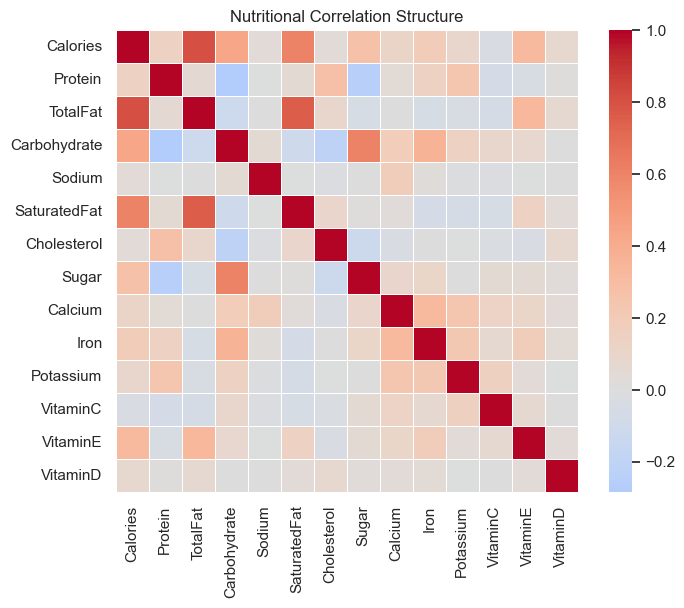

In [28]:
# Correlation visualization using heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5,
    square=True
)
plt.title("Nutritional Correlation Structure")
plt.show

### Structural Interpretation of Nutritional Correlations

The correlation matrix reveals several meaningful structural relationships among nutritional variables, highlighting how certain nutrients tend to co-occur due to shared biochemical composition or common food sources.

**Energy–Fat Coupling**

Calories show a strong positive correlation with total fat (r ≈ 0.81).
This reflects the high caloric density of fat, making fat a dominant contributor to overall energy density.

**Fat Composition Structure**

Total fat is strongly correlated with saturated fat (r ≈ 0.75), indicating that saturated fat is structurally embedded within the total fat dimension.

**Carbohydrate–Sugar Dependency**

Sugar exhibits a strong correlation with carbohydrates (r ≈ 0.61), confirming that sugar behaves as a subcomponent of the carbohydrate nutritional dimension.

**Protein–Carbohydrate Trade-off**

Protein and carbohydrate show a moderate negative correlation (r ≈ -0.28), suggesting that foods often emphasize either protein-rich or carbohydrate-rich compositions.

**Micronutrient Co-occurrence**

Some micronutrients, such as calcium and iron, show moderate positive correlation (r ≈ 0.32), indicating  that certain food categories can simultaneously provide multiple micronutrients.

Overall, the correlation structure suggests that nutritional variables are not independent. Instead, they form several structurally bound nutrient groups, reflecting underlying biochemical relationships and common dietary patterns.

### Macro-Micro Nutrient Dependencies

Beyond relationships among macronutrients and micronutrients individually, the correlation matrix also reveals several cross-level dependencies between macronutrients and micronutrients.

**Fat-Vitamin E Association**

Total fat shows moderate positive correlation with Vitamin E (r ≈ 0.33).
This relationship is expected because Vitamin E is a fat-soluble vitamin and frequently occurs in fat-rich foods.

**Carbohydrate-Iron Relationship**

Carbohydrates show moderate positive correlation with iron (r ≈ 0.36).
This pattern reflects the presence of iron in plant-based carbohydrate sources.

**Protein-Potassium Co-occurrence**

Protein shows moderate positive correlation with potassium (r ≈ 0.24).
This suggests that protein-rich food often contain significant potassium levels.

Overall, these macro-micro dependencies indicate that nutrient composition is influenced by the underlying structure of food categories rather than independent nutrient variation.

### Identify Redundant Nutritional Dimensions

High correlations between variables may indicate that multiple features capture overlapping structural information. Identifying such redundancy helps reveal which nutritional variables represent similar underlying dimensions of food composition.

To identify potentially redundant dimensions, the Pearson correlation matrix is examined. Feature pairs with relatively high correlation coefficients are interpreted as capturing overlapping nutritional information. In practice, correlations above approximately 0.7 are considered strong dependencies, while moderate correlations may indicate partial structural relationships.

In [29]:
# Identify highly correlated feature pairs
threshold = 0.7
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            feature_a = corr_matrix.columns[i]
            feature_b = corr_matrix.columns[j]
            high_corr_pairs.append((feature_a, feature_b, corr_value))
            
redundant_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Feature A", "Feature B", "Correlation"]
)

redundant_df

,Feature A,Feature B,Correlation
0,Calories,TotalFat,0.807766
1,TotalFat,SaturatedFat,0.754843


### Identify Highly Correlated Feature Pairs Interpertation

The correlation analysis reveals several variable pairs with strong statistical dependency.For example, calories and total fat show a strong positive correlation, reflecting the high caloric density of fat. Similarly, saturated fat is strongly correlated with total fat because it represents a structural component of total fat composition.

These relationships indicate that certain nutritional variables capture overlapping aspects of food composition, suggesting partial redundancy within the nutritional feature space.

Such redundancy motivates the use of dimensionality reduction techniques, such as Principal Component Analysis (PCA), to uncover the latent nutritional axes of the dataset.

## Principal Component Analysis (PCA)

### Transition to PCA

Prior to dimensionality reduction, the feature spase has already been standardized during the correlation analysis phase.

All nutritional viriables were transformed to zero mean and unit variance, ensuring comparebility across different measurement scales. This standaedized representation is directly reused in PCA stage.

### Principal Component Decomposition

PCA is applied to transform the standardized nutritional feature space into a set of orthogonal components. Each principal component represents a linear combination of the original variables and captures a specific direction of variance in the data. PCA reduces the dimensionality of the database while presercing its most informative structural patterns.

In [30]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(df_scaled)

# Convert to DataFrame for inspection
pca_columns = [f"PC{i+1}" for i in range(len(features))]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,6.592719,-4.469583,-1.674308,0.716166,0.367539,0.321632,-1.839882,0.062754,1.576090,0.212136,-1.695286,1.539069,1.630787,-0.029770
1,6.545481,-4.423645,-1.631803,0.746238,0.449579,0.325321,-1.829557,0.109209,1.504514,0.216249,-1.710918,1.498436,1.546767,-0.029899
2,8.351203,-5.436841,-2.009293,0.349765,-0.120274,0.352446,-2.144056,-0.005171,2.098844,0.264022,-1.954260,1.717921,1.920286,-0.033213
3,2.041188,-1.390839,0.988104,1.276129,1.194361,-0.193178,-0.900210,-0.370316,1.311196,-0.389515,0.684928,0.202116,0.662721,0.008244
4,2.200485,-1.414671,1.150321,0.984706,0.855904,-0.116010,-0.747790,-0.256032,2.124716,-0.564278,1.095609,-0.084888,0.663224,0.009724


### Interpretation of PCA Decomposition
The standardized nutritional feature space has now been projected into a new coodinate system defined by principal components.

Each principal component represents a linear combination of the original nutritional variables and captures a distinct direction of variation in the database. The first component explains the largest possible share of variance, while each subsequent component explains the maximun remaining variance under the constraint of orthogonality. 

In [31]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Cunulative variance
cumulative_variance = np.cumsum(explained_variance)
for i, var in enumerate(explained_variance):
    print(f"PC{i+1}: {var:.4f}")

PC1: 0.1927
PC2: 0.1570
PC3: 0.1167
PC4: 0.0765
PC5: 0.0760
PC6: 0.0718
PC7: 0.0663
PC8: 0.0602
PC9: 0.0521
PC10: 0.0468
PC11: 0.0393
PC12: 0.0279
PC13: 0.0163
PC14: 0.0003


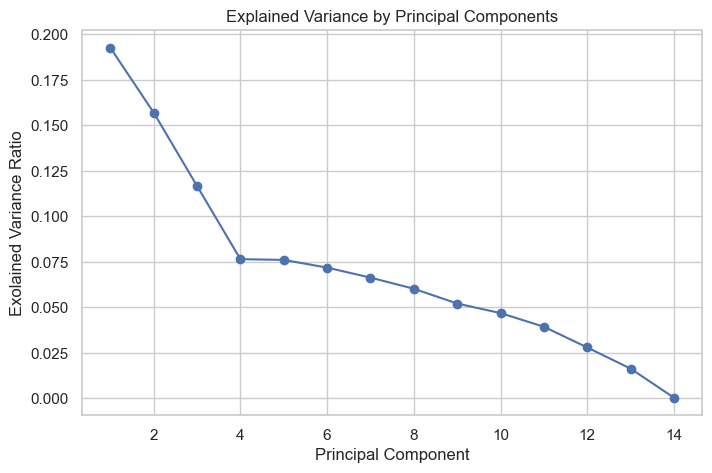

In [32]:
# Explained variance ratio virualization using line chart
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Exolained Variance Ratio")
plt.show()

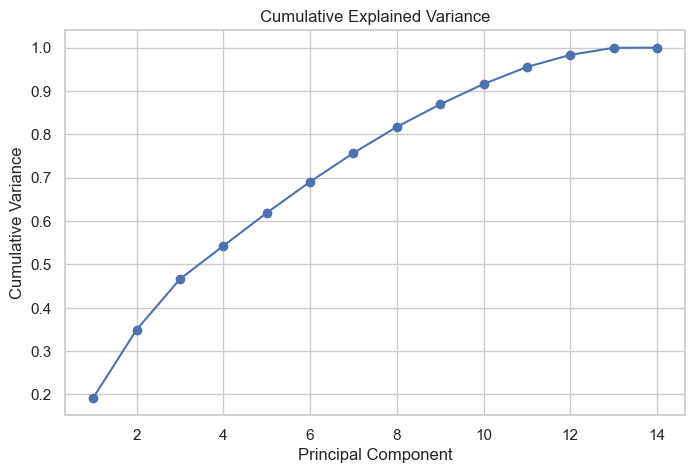

In [34]:
# Cumulative variance virualization using line chart
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance")
plt.show()

### Interpretation of Explained Variance Structure

The explained variance exhibits a gradual decay across principal components rather than a sharp drop concentrated in the first few dimensions.

The first component captures approximately 19% of the total variance, followed by the second and third components with comparable magnitudes. This indicates that no single dominant axis governs the structure of the nutritional space. Instead, variance is distributed accross multiple components.

An elbow-like transition appears at the fourth component, after which the marginal contribution of additional components decreases steadily. This indicates that the most significant structural changes are captured in the initial few dimensions, while subsequent components encode more fine-grained variations.

The cumulative variance increases smoothly, reaching approcimately 80% at eighth component and close to 90% by tenth component. This implies that  nultiple components are required to retain most of the information. The nutritional feature space cannot be effectively compressed into a very low-dimensional representation without causing significant loss of information.

Overall, this variance structure indicates that the nutritional properties of food are multi-dimensional characteristics. Several independent yet overlapping dimensions jointly determine the distribution of nutritional features.